# 🔧 Step 2 — Health Indicator Construction + Stage Labeling

**Objective**: Extract multivariate features from raw vibration signals and automatically assign degradation stage labels (Stage 1: healthy, Stage 2: early degradation, Stage 3: near-failure) using health indicator thresholds.

This notebook produces:
- Multivariate feature matrix (20 features per time step per bearing)
- Scalar health indicator for stage boundary detection
- Automatic stage labels (FPT, acceleration point, EOL)
- Stage distribution across all 15 bearings
- Visualization of stages on HI trajectories

---
## 0. Setup

In [1]:
import os, sys, shutil

# ── Clone repo (fresh every time) ─────────────────────────
REPO_PATH = "/content/RESS_2025_GAN_Conformal_RUL"
if os.path.exists(REPO_PATH):
    shutil.rmtree(REPO_PATH)
!git clone https://github.com/f-khadija-benzine/RESS_2025_GAN_Conformal_RUL.git {REPO_PATH}

os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH)
sys.path.insert(0, f"{REPO_PATH}/src")

# ── Mount Google Drive ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Find XJTU-SY on Drive ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEARCH_PATHS = [
    "/content/drive/MyDrive/datasets/XJTU-SY",
    "/content/drive/MyDrive/XJTU-SY",
    "/content/drive/MyDrive/data/XJTU-SY",
    "/content/drive/MyDrive/XJTU-SY_Bearing_Datasets",
    "/content/drive/MyDrive/datasets/XJTU-SY_Bearing_Datasets",
]
EXPECTED = {"35Hz12kN", "37.5Hz11kN", "40Hz10kN"}
DATA_ROOT = None
for p in SEARCH_PATHS:
    if os.path.exists(p):
        if EXPECTED.issubset(set(os.listdir(p))):
            DATA_ROOT = p
            break
        for sub in os.listdir(p):
            sp = os.path.join(p, sub)
            if os.path.isdir(sp) and EXPECTED.issubset(set(os.listdir(sp))):
                DATA_ROOT = sp
                break

from data_loader import XJTUSYLoader, OPERATING_CONDITIONS, CV_FOLDS, SAMPLING_RATE, SAMPLES_PER_FILE
from health_indicator import HealthIndicatorPipeline, get_all_feature_names

SAVE_DIR = f"{REPO_PATH}/results/figures"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Repo: {os.getcwd()}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print("✅ All modules imported")

Cloning into '/content/RESS_2025_GAN_Conformal_RUL'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 82 (delta 31), reused 25 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 1.25 MiB | 4.26 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Repo: /content/RESS_2025_GAN_Conformal_RUL
✅ DATA_ROOT: /content/drive/MyDrive/XJTU-SY_Bearing_Datasets
✅ All modules imported


---
## 1. Load all bearings

In [2]:
loader = XJTUSYLoader(DATA_ROOT)
all_data = loader.load_all(verbose=True)


=== Condition 1: 35.0 Hz, 12.0 kN ===
Loading Bearing1_1 (1-1): 123 recordings, failure mode: Outer race
  -> Shape: (123, 32768, 2), Memory: 32.2 MB
Loading Bearing1_2 (1-2): 161 recordings, failure mode: Outer race
  -> Shape: (161, 32768, 2), Memory: 42.2 MB
Loading Bearing1_3 (1-3): 158 recordings, failure mode: Outer race
  -> Shape: (158, 32768, 2), Memory: 41.4 MB
Loading Bearing1_4 (1-4): 122 recordings, failure mode: Cage
  -> Shape: (122, 32768, 2), Memory: 32.0 MB
Loading Bearing1_5 (1-5): 52 recordings, failure mode: Outer race + Ball
  -> Shape: (52, 32768, 2), Memory: 13.6 MB

=== Condition 2: 37.5 Hz, 11.0 kN ===
Loading Bearing2_1 (2-1): 491 recordings, failure mode: Inner race
  -> Shape: (491, 32768, 2), Memory: 128.7 MB
Loading Bearing2_2 (2-2): 161 recordings, failure mode: Outer race
  -> Shape: (161, 32768, 2), Memory: 42.2 MB
Loading Bearing2_3 (2-3): 533 recordings, failure mode: Cage
  -> Shape: (533, 32768, 2), Memory: 139.7 MB
Loading Bearing2_4 (2-4): 42 re

---
## 2. Process all bearings: extract features + assign stages

In [3]:
pipeline = HealthIndicatorPipeline(
    hi_method='simple_rms',       # simple RMS for stage detection
    smoothing_window=3,           # moving average window
    fpt_consecutive=2,            # 2 consecutive exceedances for FPT
    acceleration_sigma=1.0,       # sigma factor for acceleration point
)

results = pipeline.process_all(all_data, verbose=True)

Processing Bearing1_1...
  FPT: t=69 min | Acc: t=119 min | EOL: t=122 min
  Stages: S1=69, S2=50, S3=4
Processing Bearing1_2...
  FPT: t=35 min | Acc: t=118 min | EOL: t=160 min
  Stages: S1=35, S2=83, S3=43
Processing Bearing1_3...
  FPT: t=58 min | Acc: t=107 min | EOL: t=157 min
  Stages: S1=58, S2=49, S3=51
Processing Bearing1_4...
  FPT: t=83 min | Acc: t=104 min | EOL: t=121 min
  Stages: S1=83, S2=21, S3=18
Processing Bearing1_5...
  FPT: t=28 min | Acc: t=39 min | EOL: t=51 min
  Stages: S1=28, S2=11, S3=13
Processing Bearing2_1...
  FPT: t=452 min | Acc: t=474 min | EOL: t=490 min
  Stages: S1=452, S2=22, S3=17
Processing Bearing2_2...
  FPT: t=45 min | Acc: t=144 min | EOL: t=160 min
  Stages: S1=45, S2=99, S3=17
Processing Bearing2_3...
  FPT: t=127 min | Acc: t=336 min | EOL: t=532 min
  Stages: S1=127, S2=209, S3=197
Processing Bearing2_4...
  FPT: t=11 min | Acc: t=28 min | EOL: t=41 min
  Stages: S1=11, S2=17, S3=14
Processing Bearing2_5...
  FPT: t=121 min | Acc: t=229

---
## 3. Visualize stages for a sample bearing

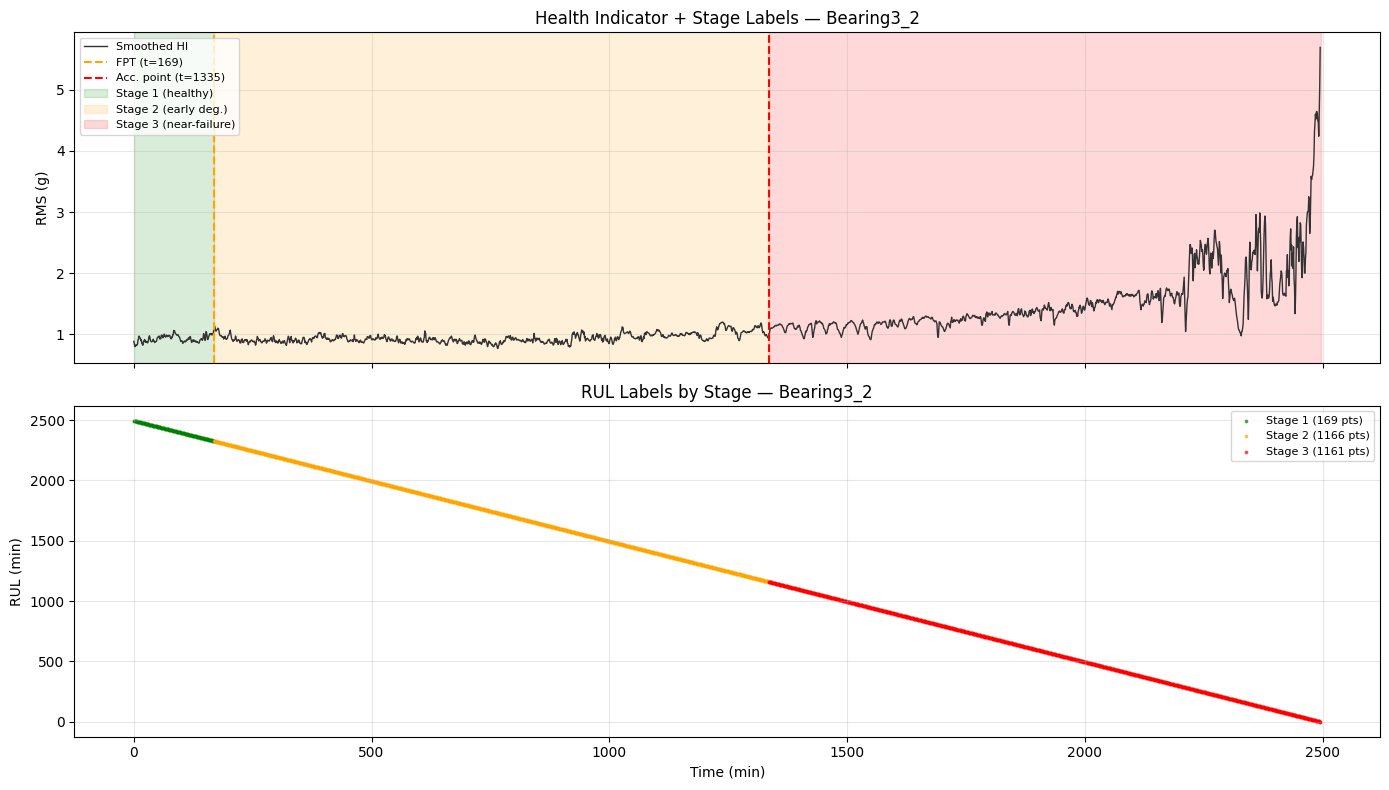

In [4]:
# Pick a bearing with a clear degradation trajectory
sample_bid = "Bearing3_2"
r = results[sample_bid]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

time = np.arange(len(r['hi_smoothed']))

# Plot 1: HI with stage boundaries
ax = axes[0]
ax.plot(time, r['hi_smoothed'], color='#333333', lw=1, label='Smoothed HI')
ax.axvline(r['fpt_idx'], color='orange', ls='--', lw=1.5, label=f"FPT (t={r['fpt_idx']})")
ax.axvline(r['acc_idx'], color='red', ls='--', lw=1.5, label=f"Acc. point (t={r['acc_idx']})")

# Color background by stage
ax.axvspan(0, r['fpt_idx'], alpha=0.15, color='green', label='Stage 1 (healthy)')
ax.axvspan(r['fpt_idx'], r['acc_idx'], alpha=0.15, color='orange', label='Stage 2 (early deg.)')
ax.axvspan(r['acc_idx'], len(time), alpha=0.15, color='red', label='Stage 3 (near-failure)')

ax.set_ylabel('RMS (g)')
ax.set_title(f'Health Indicator + Stage Labels — {sample_bid}')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: RUL with stage colors
ax2 = axes[1]
colors_stage = {1: 'green', 2: 'orange', 3: 'red'}
for stage in [1, 2, 3]:
    mask = r['stage_labels'] == stage
    ax2.scatter(time[mask], r['rul'][mask], c=colors_stage[stage], s=3, alpha=0.6,
                label=f'Stage {stage} ({r["stage_counts"][stage]} pts)')

ax2.set_xlabel('Time (min)')
ax2.set_ylabel('RUL (min)')
ax2.set_title(f'RUL Labels by Stage — {sample_bid}')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_stage_labels_sample.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Stage labels for all 15 bearings

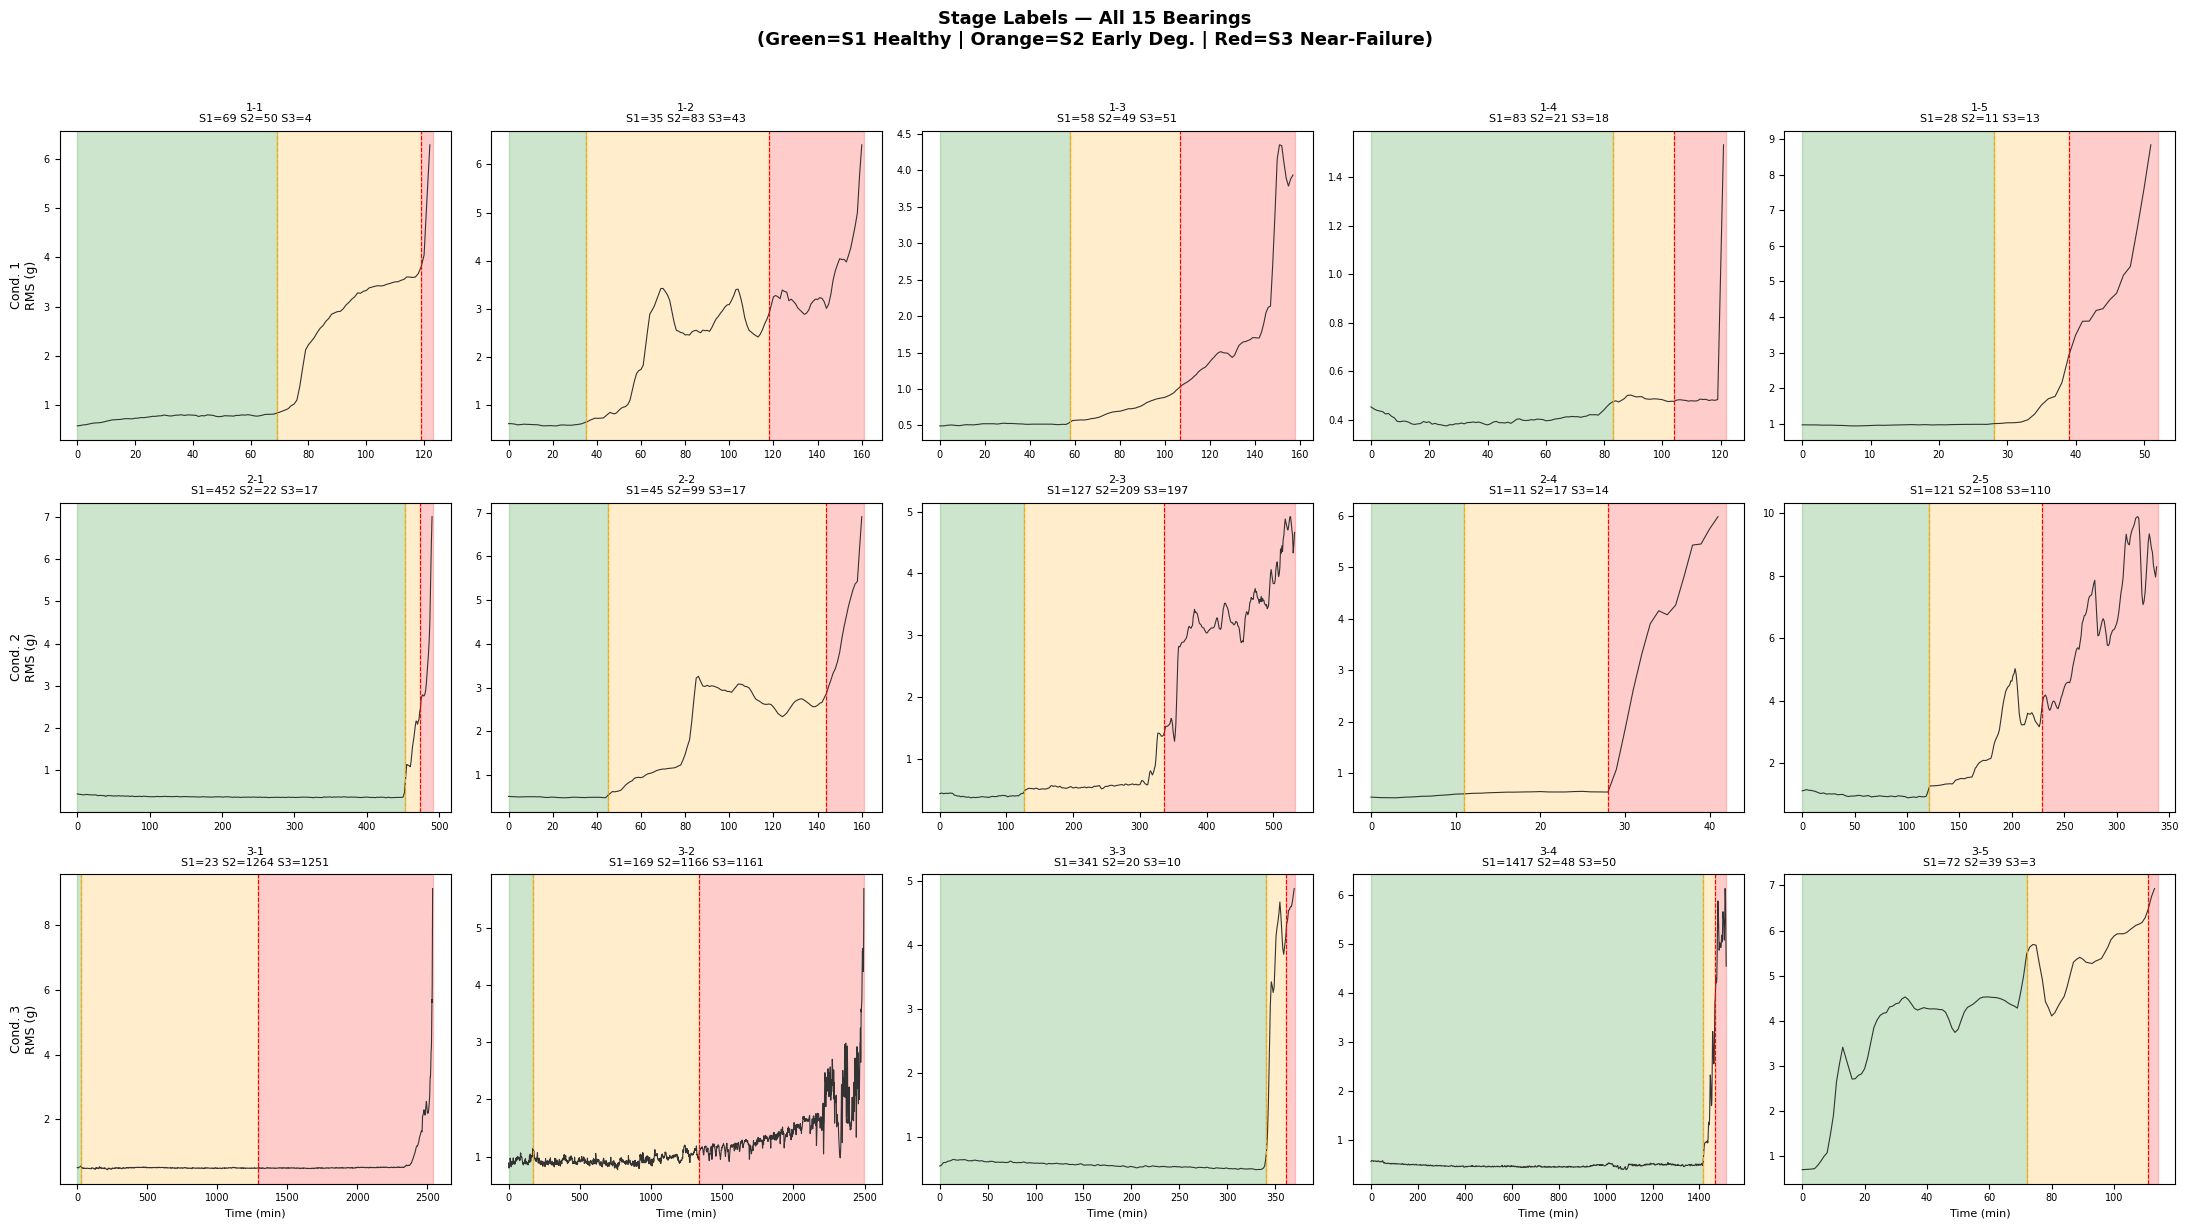

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
colors = {1: '#2196F3', 2: '#FF9800', 3: '#4CAF50'}

for cond in [1, 2, 3]:
    for j, bid in enumerate(OPERATING_CONDITIONS[cond]['bearings']):
        ax = axes[cond - 1, j]
        r = results[bid]
        time = np.arange(len(r['hi_smoothed']))

        # Plot HI
        ax.plot(time, r['hi_smoothed'], color='#333333', lw=0.8)

        # Color background by stage
        ax.axvspan(0, r['fpt_idx'], alpha=0.2, color='green')
        ax.axvspan(r['fpt_idx'], r['acc_idx'], alpha=0.2, color='orange')
        ax.axvspan(r['acc_idx'], len(time), alpha=0.2, color='red')

        # Mark boundaries
        ax.axvline(r['fpt_idx'], color='orange', ls='--', lw=0.8)
        ax.axvline(r['acc_idx'], color='red', ls='--', lw=0.8)

        sc = r['stage_counts']
        short_id = bid.replace('Bearing', '').replace('_', '-')
        ax.set_title(f'{short_id}\nS1={sc[1]} S2={sc[2]} S3={sc[3]}', fontsize=8)

        if j == 0:
            ax.set_ylabel(f'Cond. {cond}\nRMS (g)', fontsize=9)
        if cond == 3:
            ax.set_xlabel('Time (min)', fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle('Stage Labels — All 15 Bearings\n'
             '(Green=S1 Healthy | Orange=S2 Early Deg. | Red=S3 Near-Failure)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_all_bearings_stages.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Global stage distribution

GLOBAL STAGE DISTRIBUTION
  Stage 1:  3051 recordings ( 33.1%)
  Stage 2:  3206 recordings ( 34.8%)
  Stage 3:  2959 recordings ( 32.1%)
  Total:   9216

PER-BEARING STAGE DISTRIBUTION
bearing   S1   S2   S3  total    S3_pct
    1-1   69   50    4    123  3.252033
    1-2   35   83   43    161 26.708075
    1-3   58   49   51    158 32.278481
    1-4   83   21   18    122 14.754098
    1-5   28   11   13     52 25.000000
    2-1  452   22   17    491  3.462322
    2-2   45   99   17    161 10.559006
    2-3  127  209  197    533 36.960600
    2-4   11   17   14     42 33.333333
    2-5  121  108  110    339 32.448378
    3-1   23 1264 1251   2538 49.290780
    3-2  169 1166 1161   2496 46.514423
    3-3  341   20   10    371  2.695418
    3-4 1417   48   50   1515  3.300330
    3-5   72   39    3    114  2.631579


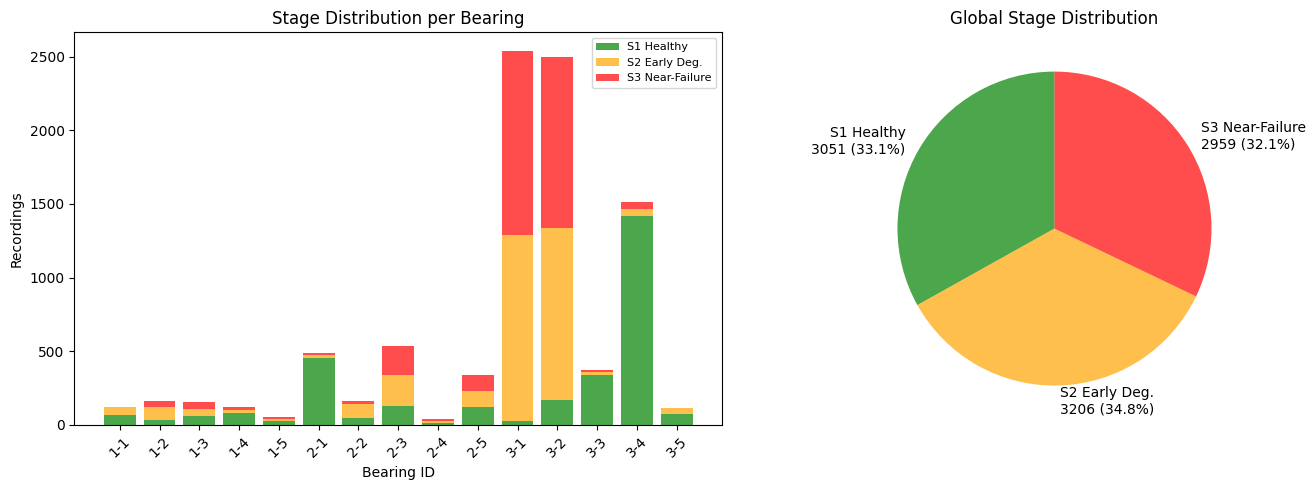

In [6]:
# Aggregate stage counts
total_stages = {1: 0, 2: 0, 3: 0}
per_bearing = []

for bid, r in results.items():
    sc = r['stage_counts']
    short_id = bid.replace('Bearing', '').replace('_', '-')
    per_bearing.append({
        'bearing': short_id,
        'S1': sc[1], 'S2': sc[2], 'S3': sc[3],
        'total': sc[1] + sc[2] + sc[3],
        'S3_pct': 100 * sc[3] / (sc[1] + sc[2] + sc[3])
    })
    for s in [1, 2, 3]:
        total_stages[s] += sc[s]

df_stages = pd.DataFrame(per_bearing)
total = sum(total_stages.values())

print("=" * 60)
print("GLOBAL STAGE DISTRIBUTION")
print("=" * 60)
for s in [1, 2, 3]:
    pct = 100 * total_stages[s] / total
    print(f"  Stage {s}: {total_stages[s]:>5d} recordings ({pct:>5.1f}%)")
print(f"  Total:  {total:>5d}")

print("\n" + "=" * 60)
print("PER-BEARING STAGE DISTRIBUTION")
print("=" * 60)
print(df_stages.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
bottoms_s2 = df_stages['S1'].values
bottoms_s3 = df_stages['S1'].values + df_stages['S2'].values

axes[0].bar(df_stages['bearing'], df_stages['S1'], color='green', alpha=0.7, label='S1 Healthy')
axes[0].bar(df_stages['bearing'], df_stages['S2'], bottom=bottoms_s2, color='orange', alpha=0.7, label='S2 Early Deg.')
axes[0].bar(df_stages['bearing'], df_stages['S3'], bottom=bottoms_s3, color='red', alpha=0.7, label='S3 Near-Failure')
axes[0].set_xlabel('Bearing ID')
axes[0].set_ylabel('Recordings')
axes[0].set_title('Stage Distribution per Bearing')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8)

# Pie chart global
axes[1].pie(
    [total_stages[1], total_stages[2], total_stages[3]],
    labels=[f'S1 Healthy\n{total_stages[1]} ({100*total_stages[1]/total:.1f}%)',
            f'S2 Early Deg.\n{total_stages[2]} ({100*total_stages[2]/total:.1f}%)',
            f'S3 Near-Failure\n{total_stages[3]} ({100*total_stages[3]/total:.1f}%)'],
    colors=['green', 'orange', 'red'],
    autopct='', startangle=90,
    wedgeprops={'alpha': 0.7}
)
axes[1].set_title('Global Stage Distribution')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Multivariate feature matrix preview

Feature matrix shape: (2496, 20)
  → 2496 time steps × 20 features

Feature names (20):
  [ 0] horiz_rms
  [ 1] horiz_peak
  [ 2] horiz_peak_to_peak
  [ 3] horiz_std
  [ 4] horiz_kurtosis
  [ 5] horiz_skewness
  [ 6] horiz_crest_factor
  [ 7] horiz_shape_factor
  [ 8] horiz_impulse_factor
  [ 9] horiz_clearance_factor
  [10] vert_rms
  [11] vert_peak
  [12] vert_peak_to_peak
  [13] vert_std
  [14] vert_kurtosis
  [15] vert_skewness
  [16] vert_crest_factor
  [17] vert_shape_factor
  [18] vert_impulse_factor
  [19] vert_clearance_factor


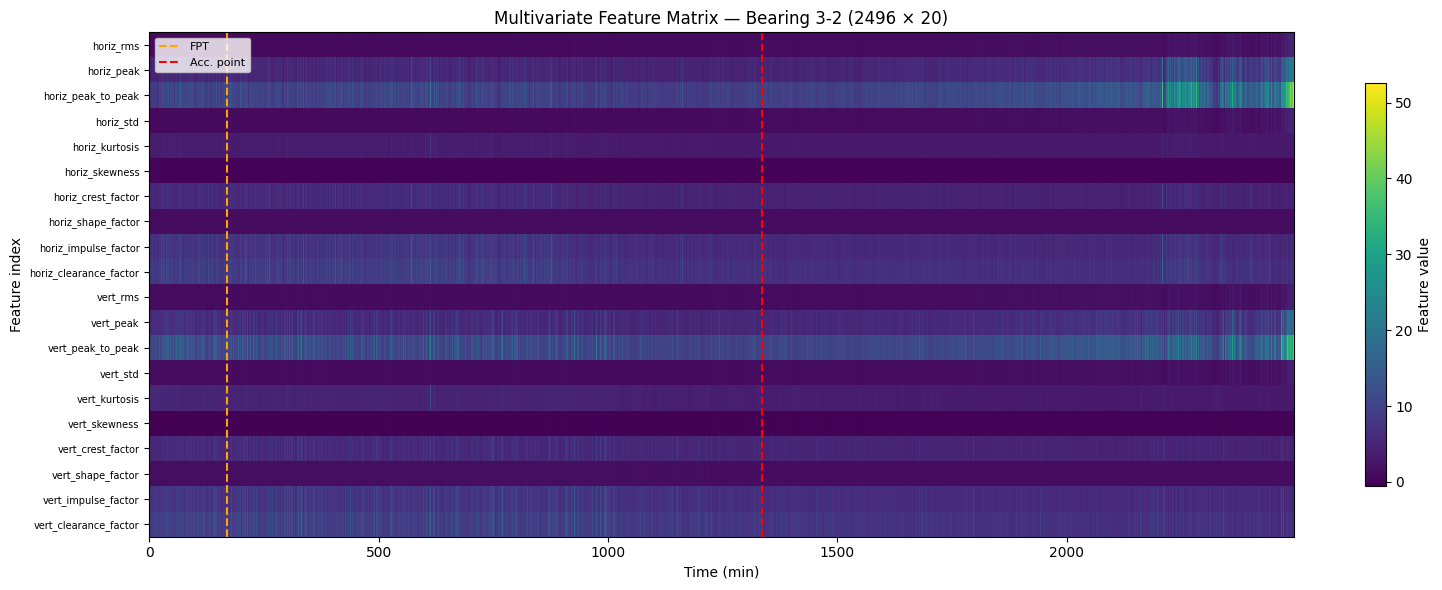

In [7]:
# Show feature matrix for one bearing
r = results['Bearing3_2']
feat_names = r['feature_names']

print(f"Feature matrix shape: {r['features'].shape}")
print(f"  → {r['features'].shape[0]} time steps × {r['features'].shape[1]} features")
print(f"\nFeature names ({len(feat_names)}):")
for i, name in enumerate(feat_names):
    print(f"  [{i:2d}] {name}")

# Heatmap of features over time
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(r['features'].T, aspect='auto', cmap='viridis',
               interpolation='nearest')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Feature index')
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names, fontsize=7)
ax.set_title(f'Multivariate Feature Matrix — Bearing 3-2 ({r["features"].shape[0]} × {r["features"].shape[1]})')

# Mark stage boundaries
ax.axvline(r['fpt_idx'], color='orange', ls='--', lw=1.5, label='FPT')
ax.axvline(r['acc_idx'], color='red', ls='--', lw=1.5, label='Acc. point')
ax.legend(loc='upper left', fontsize=8)

plt.colorbar(im, ax=ax, label='Feature value', shrink=0.8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_feature_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature correlation between channels

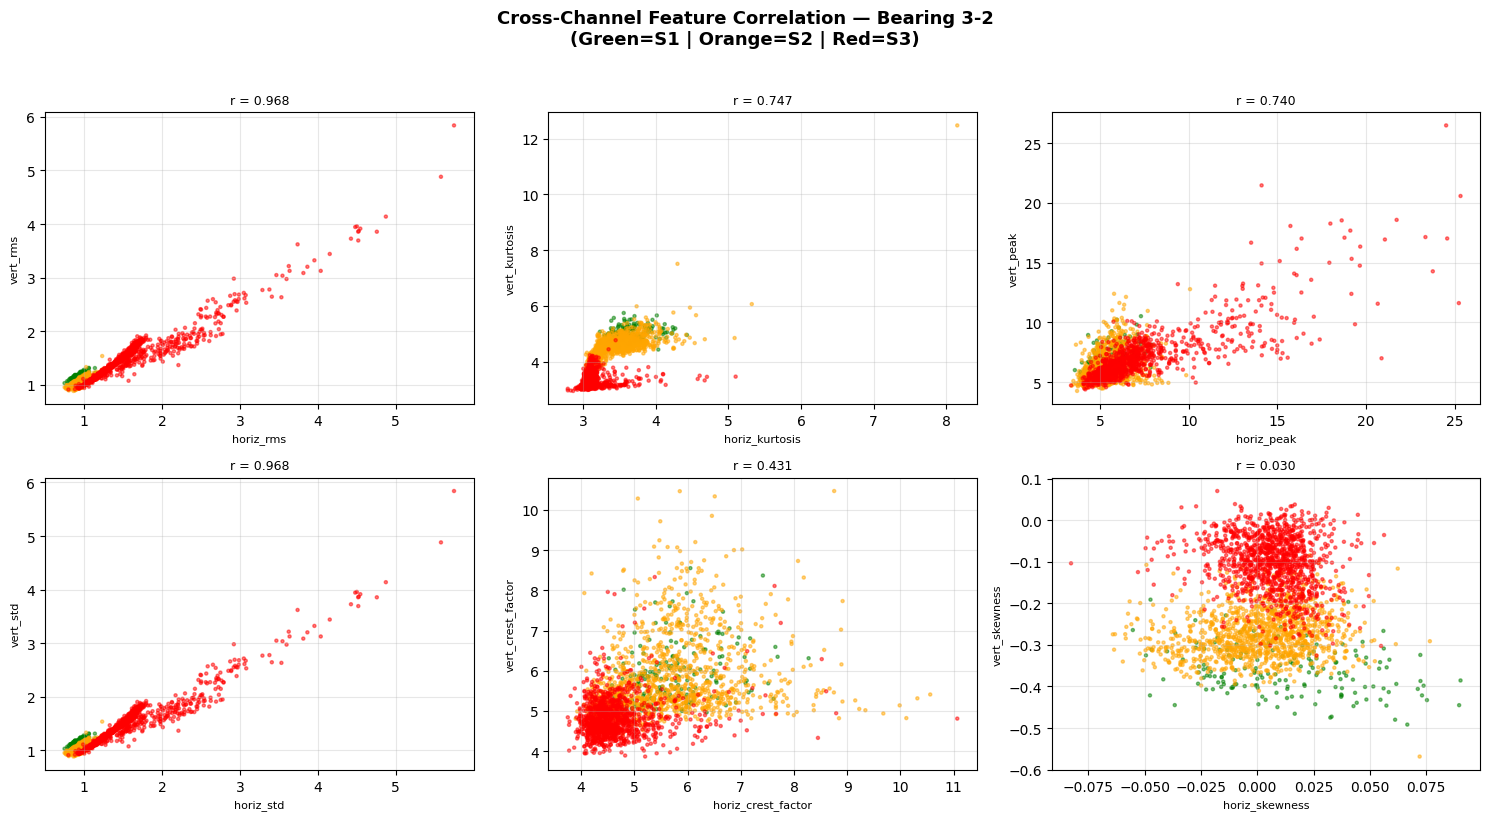

In [8]:
# Show that horizontal and vertical features are correlated but not identical
r = results['Bearing3_2']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_pairs = [
    ('horiz_rms', 'vert_rms', 0, 10),
    ('horiz_kurtosis', 'vert_kurtosis', 4, 14),
    ('horiz_peak', 'vert_peak', 1, 11),
    ('horiz_std', 'vert_std', 3, 13),
    ('horiz_crest_factor', 'vert_crest_factor', 6, 16),
    ('horiz_skewness', 'vert_skewness', 5, 15),
]

for ax, (name_h, name_v, idx_h, idx_v) in zip(axes.flat, feature_pairs):
    stage_colors = ['green' if s == 1 else 'orange' if s == 2 else 'red'
                    for s in r['stage_labels']]
    ax.scatter(r['features'][:, idx_h], r['features'][:, idx_v],
               c=stage_colors, s=5, alpha=0.5)
    corr = np.corrcoef(r['features'][:, idx_h], r['features'][:, idx_v])[0, 1]
    ax.set_xlabel(name_h, fontsize=8)
    ax.set_ylabel(name_v, fontsize=8)
    ax.set_title(f'r = {corr:.3f}', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Cross-Channel Feature Correlation — Bearing 3-2\n'
             '(Green=S1 | Orange=S2 | Red=S3)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_cross_channel_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Summary

In [9]:
print("=" * 60)
print("STEP 2 SUMMARY")
print("=" * 60)
print(f"Health indicator method: simple RMS (horizontal channel)")
print(f"Smoothing window: 3")
print(f"FPT detection: 2-sigma, 2 consecutive exceedances")
print(f"Number of features per time step: {results['Bearing1_1']['features'].shape[1]}")
print(f"Feature names: {get_all_feature_names()}")
print(f"\nGlobal stage distribution:")
for s in [1, 2, 3]:
    pct = 100 * total_stages[s] / total
    print(f"  Stage {s}: {total_stages[s]} ({pct:.1f}%)")
print(f"\nData scarcity ratio (S1:S3): {total_stages[1] / max(total_stages[3], 1):.1f}:1")
print(f"\nFigures saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    if f.startswith('02_'):
        print(f"  {f}")
print("\n✅ Step 2 complete. Proceed to Step 3 (windowing + splits).")

STEP 2 SUMMARY
Health indicator method: simple RMS (horizontal channel)
Smoothing window: 3
FPT detection: 2-sigma, 2 consecutive exceedances
Number of features per time step: 20
Feature names: ['horiz_rms', 'horiz_peak', 'horiz_peak_to_peak', 'horiz_std', 'horiz_kurtosis', 'horiz_skewness', 'horiz_crest_factor', 'horiz_shape_factor', 'horiz_impulse_factor', 'horiz_clearance_factor', 'vert_rms', 'vert_peak', 'vert_peak_to_peak', 'vert_std', 'vert_kurtosis', 'vert_skewness', 'vert_crest_factor', 'vert_shape_factor', 'vert_impulse_factor', 'vert_clearance_factor']

Global stage distribution:
  Stage 1: 3051 (33.1%)
  Stage 2: 3206 (34.8%)
  Stage 3: 2959 (32.1%)

Data scarcity ratio (S1:S3): 1.0:1

Figures saved:
  02_all_bearings_stages.png
  02_cross_channel_correlation.png
  02_feature_matrix_heatmap.png
  02_stage_distribution.png
  02_stage_labels_sample.png

✅ Step 2 complete. Proceed to Step 3 (windowing + splits).
